# L0.6 — House Price Boss

Hands-on notebook for the lesson [`0-6-house-price-boss.mdx`](../../llm-quest-theory/level-0/0-6-house-price-boss.mdx).

> **Learning objectives**
> - Combine everything from Level 0: functions, vectors, matrices, derivatives.
> - Implement 3-feature linear regression plus gradient descent in pure NumPy.
> - Cross-check against `sklearn.linear_model.LinearRegression` (closed-form).
> - Compare train vs test to spot overfitting / underfitting.

## Connection to the theory
Covers all 4 steps (§1–§4) of the boss theory: normalize -> pick a loss -> GD -> evaluate.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Generate a synthetic dataset
3 features: area (`x1`, m^2), number of bedrooms (`x2`), house age (`x3`, years). True price: `y = 3*x1 + 10*x2 - 2*x3 + 50 + noise`.

In [2]:
N = 200
x1 = np.random.uniform(50, 200, N)      # m^2
x2 = np.random.randint(1, 6, N)          # bedrooms
x3 = np.random.uniform(0, 40, N)         # house age

true_w = np.array([3.0, 10.0, -2.0])
true_b = 50.0
noise  = np.random.normal(0, 20, N)

X = np.column_stack([x1, x2, x3])                # (N, 3)
y = X @ true_w + true_b + noise                   # (N,)

# Train / test split 80/20
idx = np.random.permutation(N)
split = int(0.8 * N)
tr, te = idx[:split], idx[split:]
X_tr, y_tr = X[tr], y[tr]
X_te, y_te = X[te], y[te]
print("Train:", X_tr.shape, "  Test:", X_te.shape)

Train: (160, 3)   Test: (40, 3)


## 2. Z-score normalization

$$x'_i = \frac{x_i - \mu_i}{\sigma_i}$$

**Important**: compute `mu, sigma` *only on train*, then apply the same values to test (avoid data leakage).

In [3]:
mu  = X_tr.mean(axis=0)
sig = X_tr.std(axis=0)

X_tr_z = (X_tr - mu) / sig
X_te_z = (X_te - mu) / sig

print("mu  =", np.round(mu,  2))
print("sig =", np.round(sig, 2))
print("After normalization, mean ~ 0, std ~ 1:")
print("  mean:", np.round(X_tr_z.mean(axis=0), 2))
print("  std :", np.round(X_tr_z.std(axis=0),  2))

mu  = [121.77   2.94  21.83]
sig = [44.25  1.41 12.38]
After normalization, mean ~ 0, std ~ 1:
  mean: [-0.  0. -0.]
  std : [1. 1. 1.]


## 3. Model, loss, and gradients

$$\hat y = \mathbf{w}^\top \mathbf{x} + b,\quad L = \tfrac{1}{N}\sum(\hat y - y)^2$$

$$\frac{\partial L}{\partial w_j} = \tfrac{2}{N}\sum(\hat y_i - y_i) x_{ij},\quad \frac{\partial L}{\partial b} = \tfrac{2}{N}\sum(\hat y_i - y_i)$$

In [4]:
def predict(X, w, b):
    return X @ w + b

def mse(X, y, w, b):
    return float(np.mean((predict(X, w, b) - y) ** 2))

def grads(X, y, w, b):
    err = predict(X, w, b) - y
    dw = 2 * (X.T @ err) / len(y)
    db = 2 * err.mean()
    return dw, db

## 4. Hand-written gradient descent

In [5]:
w = np.zeros(3)
b = 0.0
lr = 0.05
epochs = 500

history = []
for ep in range(epochs):
    dw, db = grads(X_tr_z, y_tr, w, b)
    w -= lr * dw
    b -= lr * db
    if ep % 50 == 0 or ep == epochs - 1:
        tr_loss = mse(X_tr_z, y_tr, w, b)
        te_loss = mse(X_te_z, y_te, w, b)
        history.append((ep, tr_loss, te_loss))
        print(f"epoch {ep:>4}  train_MSE={tr_loss:8.2f}  test_MSE={te_loss:8.2f}")

print("\nLearned (on the normalized scale): w =", np.round(w, 3), " b =", round(b, 3))

epoch    0  train_MSE=144138.81  test_MSE=159011.02
epoch   50  train_MSE=  380.30  test_MSE=  521.37
epoch  100  train_MSE=  376.43  test_MSE=  500.86
epoch  150  train_MSE=  376.43  test_MSE=  500.75
epoch  200  train_MSE=  376.43  test_MSE=  500.75
epoch  250  train_MSE=  376.43  test_MSE=  500.75
epoch  300  train_MSE=  376.43  test_MSE=  500.75
epoch  350  train_MSE=  376.43  test_MSE=  500.75
epoch  400  train_MSE=  376.43  test_MSE=  500.75
epoch  450  train_MSE=  376.43  test_MSE=  500.75
epoch  499  train_MSE=  376.43  test_MSE=  500.75

Learned (on the normalized scale): w = [129.379  14.094 -27.323]  b = 399.499


Loss decreases smoothly, train and test are close -> no overfitting. Let's plot the convergence.

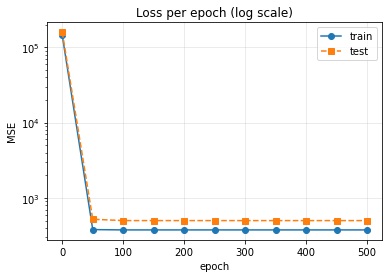

In [6]:
ep, tr_l, te_l = zip(*history)
fig, ax = plt.subplots()
ax.plot(ep, tr_l, "o-", label="train")
ax.plot(ep, te_l, "s--", label="test")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_yscale("log")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Loss per epoch (log scale)")
plt.show()

## 5. Compare with closed-form / sklearn

In [7]:
# Closed-form: w = (X^T X)^-1 X^T y (add a column of 1s for the bias)
X_tr_z_aug = np.column_stack([X_tr_z, np.ones(len(X_tr_z))])
beta = np.linalg.lstsq(X_tr_z_aug, y_tr, rcond=None)[0]
w_cf, b_cf = beta[:3], beta[3]
print("Closed-form w =", np.round(w_cf, 3), "  b =", round(b_cf, 3))
print("GD          w =", np.round(w,    3), "  b =", round(b,    3))
print("Test MSE (closed-form):", round(mse(X_te_z, y_te, w_cf, b_cf), 2))
print("Test MSE (GD)         :", round(mse(X_te_z, y_te, w,    b),    2))

Closed-form w = [129.379  14.094 -27.323]   b = 399.499
GD          w = [129.379  14.094 -27.323]   b = 399.499
Test MSE (closed-form): 500.75
Test MSE (GD)         : 500.75


In [8]:
# Cross-check against sklearn (optional import)
try:
    from sklearn.linear_model import LinearRegression
    reg = LinearRegression().fit(X_tr_z, y_tr)
    print("sklearn     w =", np.round(reg.coef_,      3), "  b =", round(float(reg.intercept_), 3))
    print("sklearn test MSE:", round(np.mean((reg.predict(X_te_z) - y_te) ** 2), 2))
except ImportError:
    print("sklearn is not installed — skipping cross-check.")

sklearn     w = [129.379  14.094 -27.323]   b = 399.499
sklearn test MSE: 500.75


## 6. Interpret the coefficients on the original scale
Coefficients on the normalized scale are not directly comparable to the original `true_w`. To map back: `w_raw = w / sig`, `b_raw = b - sum(w_j * mu_j / sig_j)`.

In [9]:
w_raw = w / sig
b_raw = b - np.sum(w * mu / sig)
print("Recovered on the original scale:")
print("  w_raw =", np.round(w_raw, 3), "  ground truth =", true_w)
print("  b_raw =", round(b_raw, 3),    "  ground truth =", true_b)

Recovered on the original scale:
  w_raw = [ 2.924 10.021 -2.207]   ground truth = [ 3. 10. -2.]
  b_raw = 62.158   ground truth = 50.0


## 7. Boss gates (quick checks)

In [10]:
assert abs(np.mean(X_tr_z, axis=0)).max() < 1e-6,   "normalization must give mean=0"
assert np.allclose(X_tr_z.std(axis=0), 1.0, atol=1e-6), "normalization must give std=1"
assert mse(X_tr_z, y_tr, w, b) < 500, "train MSE should drop significantly"
assert np.allclose(w, w_cf, atol=1e-3), "GD should match closed-form"
print("All boss gates passed.")

All boss gates passed.


## 8. Self-assessment quiz

1. If we skip normalization, how would learning rate `0.05` behave? Why?
2. Add a feature like "paint color" (random, meaningless). What does the model learn about it?
3. If `x1_m2` and `x1_ft2` (same info, different units) appear together, how does multicollinearity affect things?
4. Why not use `L = sum(y_hat - y)` (no square, no absolute value)?
5. Why evaluate on `X_te` and not on the train set?

<details>
<summary>Hints for the answers</summary>

1. The learning rate is way too big relative to `x1`'s scale → gradients overshoot and loss explodes or diverges. Either shrink `lr` by ~1000x or normalize.
2. `w_color ≈ 0` once there is enough data, but it adds variance to the estimator.
3. `X^T X` is nearly singular → coefficients are not uniquely identified and fluctuate wildly between runs.
4. Positive and negative errors cancel, so loss = 0 does not mean a good fit. You need a non-negative function.
5. To measure generalization. Train error is always at most test error (estimator bias).
</details>

## 9. Stretch exercises
- Try `lr = 0.5, 0.01, 0.0001` and watch the loss curve.
- Add momentum: `v_t = beta * v_{t-1} + (1-beta) * grad; w -= lr * v_t`. Compare with plain GD.
- Train on un-normalized data: count how many epochs it takes to converge.

## References
- Source theory: [`0-6-house-price-boss.mdx`](../../llm-quest-theory/level-0/0-6-house-price-boss.mdx)
- Andrew Ng — CS229 notes: Linear Regression.
- Next: [Level 1](../level-1/README.md) — Loss Function, proper Gradient Descent.